In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from src.algos.esprit import esprit_cosine
from src.algos.power_law import power_law
from src.algos.glsae import glsae
from src.algos.gdmae import gdmae

import json

rng = np.random.default_rng()
target = 1/np.pi

In [2]:
with open('./output/uniform/esprit.jsonl', 'w') as f:
    for j in range(100):
        res = [esprit_cosine(target, i, 16, rng) for i in 2 ** np.arange(1, 10)]
        y, x, z = zip(*res)
        json.dump({"query": np.array(x).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
        f.write("\n")

In [3]:
with open('./output/uniform/powerlaw.jsonl', 'w') as f:
    for j in range(100):
        res = [power_law(target, 0.5/i, 1/3.0, rng, n_shots=16) for i in 2 ** np.arange(0, 12)]
        y, x, z = zip(*res)
        json.dump({"query": np.array(x).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
        f.write("\n")

In [4]:
with open('./output/uniform/glsae.jsonl', 'w') as f:
    for j in range(100):
        res = [glsae(target, i, i**2*4, rng, G=np.ceil(i**0.5)*8) for i in 2 ** np.arange(1, 10)]
        y, x, z = zip(*res)
        json.dump({"query": np.array(x).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
        f.write("\n")

In [5]:
with open('./output/uniform/gdmae.jsonl', 'w') as f:
    for j in range(100):
        res = [gdmae(target, i, i**2*2, rng, G=np.ceil(i**0.5)*8) for i in 2 ** np.arange(1, 10)]
        y, x, z = zip(*res)
        json.dump({"query": (2*np.array(x)).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
        f.write("\n")

In [6]:
plt.rcParams.update({'font.size': 15, 'font.family': "serif","font.serif": "CMU Serif", 'text.usetex': True})

In [7]:
algos = ["ESPRIT", "PowerLaw", "GLSAE", "GDMAE"]
linestyle_tuple = [
     ('dotted',                (0, (1, 2))),
     ('densely dotted',        (0, (1, 1))),
     ('dashed',                (0, (5, 3))),
     ('densely dashed',        (0, (3, 1)))]

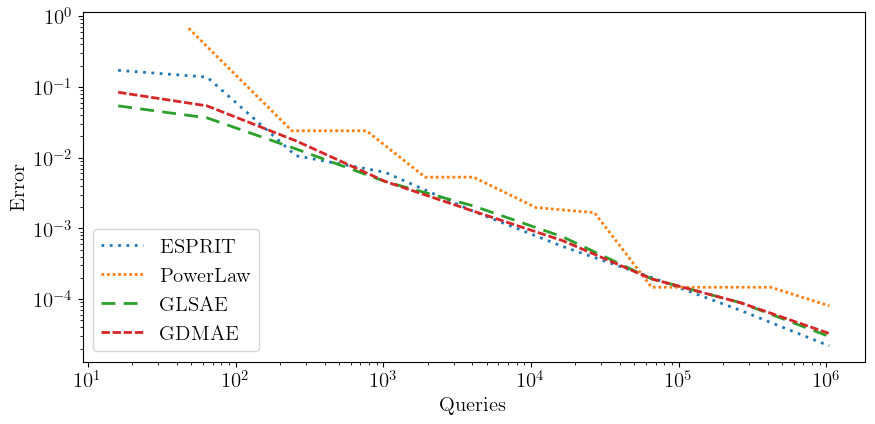

In [8]:
fig, ax = plt.subplots(figsize=(9,4.5))
for algo, (_,style) in zip(algos,linestyle_tuple):
    with open(f'./output/uniform/{algo.lower()}.jsonl', 'r') as json_file:
        json_list = list(json_file)
    time = []
    value = []
    for json_str in json_list:
        res = json.loads(json_str)
        time.append(res["query"])
        value.append(res["value"])
    time = np.max(time,axis=0)
    error = np.median(np.abs(np.array(value)-target), axis=0)
    plt.plot(time,error,label=algo,linestyle=style,linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Queries")
plt.ylabel("Error")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("compare_query.pdf", bbox_inches='tight')

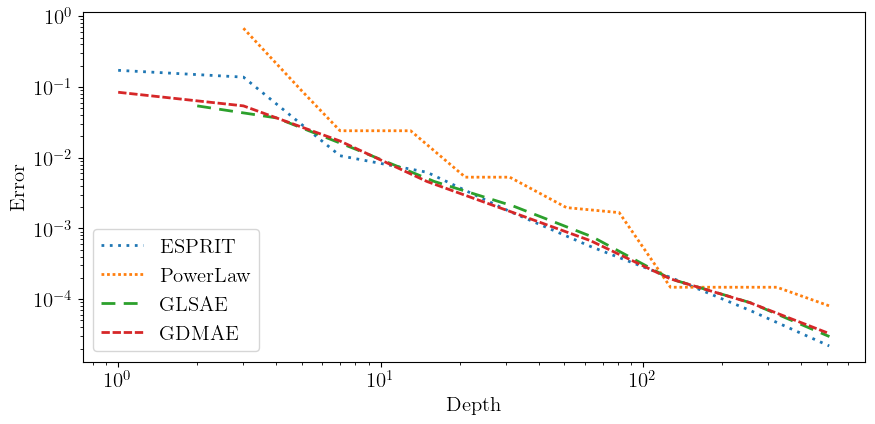

In [9]:
fig, ax = plt.subplots(figsize=(9,4.5))
for algo, (_,style) in zip(algos,linestyle_tuple):
    with open(f'./output/uniform/{algo.lower()}.jsonl', 'r') as json_file:
        json_list = list(json_file)
    time = []
    value = []
    for json_str in json_list:
        res = json.loads(json_str)
        time.append(res["depth"])
        value.append(res["value"])
    time = np.max(time,axis=0)
    error = np.median(np.abs(np.array(value)-target), axis=0)
    plt.plot(time,error,label=algo,linestyle=style,linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Depth")
plt.ylabel("Error")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("compare_depth.pdf", bbox_inches='tight')